# 1. Постановка задачи
* **Какая целевая переменная (что предсказываем):** По тексту твита о катастрофе будем определять о реальном ли бедствии идёт речь ("Новые лесные пожары во Флориде") или в тексте представлен переносный смысл ("он сгорает от любви" и т.п.).
* **Задача классификации или регрессии (или кластеризации, или генерации текста или распознавания медицинских снимков, ...)?** NLP задача бинарной классификации текстов. В качестве итоговой модели протестируем Регрессию и Pytorch
* **Какую метрику(и) будем использовать для оценки качества:** Для оценки качества будем использовать F1, а также Precision, Recall

# 2. Загрузка данных

In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/nlp-getting-started/sample_submission.csv
/kaggle/input/nlp-getting-started/train.csv
/kaggle/input/nlp-getting-started/test.csv
/kaggle/input/world-cities-database/LICENSE.txt
/kaggle/input/world-cities-database/worldcitiespop.csv


In [2]:
df = pd.read_csv("/kaggle/input/nlp-getting-started/train.csv")
test = pd.read_csv("/kaggle/input/nlp-getting-started/test.csv")

# 3. Анализ данных

## Анализ признаков

In [3]:
df.head()

,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7613 entries, 0 to 7612
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        7613 non-null   int64 
 1   keyword   7552 non-null   object
 2   location  5080 non-null   object
 3   text      7613 non-null   object
 4   target    7613 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 297.5+ KB


Для решения задачи у нас есть признаки keyword (ключевая фраза в в твите, которая характеризует происшествие), location (географиечское место, где могло произойти происшествие) и text (текст твита)

In [5]:
# количество уникальных ключевых слов
df.loc[:,'keyword'].nunique()

221

In [6]:
# частота использования keywords
df.loc[:,'keyword'].value_counts()

fatalities               45
armageddon               42
deluge                   42
damage                   41
sinking                  41
                         ..
forest%20fire            19
epicentre                12
threat                   11
inundation               10
radiation%20emergency     9
Name: keyword, Length: 221, dtype: int64

видно, что некоторые слова необходимо декодировать, т.к. они в формате urlencoded (%20, например, означает пробел)

In [7]:
# количество уникальных локаций
df.loc[:,'location'].nunique()

3341

In [8]:
# частота использования различных location
df.loc[:,'location'].value_counts()

USA                          104
New York                      71
United States                 50
London                        45
Canada                        29
                            ... 
access to njh/5 and cth/4      1
houston                        1
denmark                        1
Every Where in the World       1
East TN.                       1
Name: location, Length: 3341, dtype: int64

## Проверка данных на сбалансированность

target
0    4342
1    3271
Name: target, dtype: int64
Доля данных, показывающих реалные происшествия "target=1" 0.43


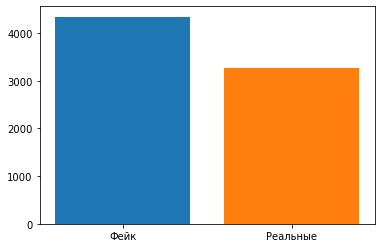

In [9]:
# описание данных
print(df.groupby('target')['target'].count())

# процент target=1
target_count = df[df['target'] == 1]['target'].count()
total = df['target'].count()
target_share = target_count/total
print("Доля данных, показывающих реалные происшествия \"target=1\" {0:.2f}".format(target_share))

# гистограмма
df[df['target'] == 0]['target'].astype(int).hist(label='Фейк', grid = False, bins=1, rwidth=0.8)
df[df['target'] == 1]['target'].astype(int).hist(label='Реальные', grid = False, bins=1, rwidth=0.8)
plt.xticks((0,1),('Фейк', 'Реальные'))
plt.show()

Вывод: данные почти сбалансированы, но не полностью.
Вследующем разделе мы проведём полную балансировку путём отбрасывания лишних фейковых твитов (перемешаем выборку фйковых твитов и удалим оттуда лишние 1071 элемент (= 4342 реальных твитов - 3271 фейковых твитов)).

## Анализ зависимостей между признаками и целевой переменной

### Распределение реальных и фейковых твитов в зависимости от географии

In [10]:
# т.к. в признаке location отсутствуют координаты, необходимые для построения карты, то добавим новую базу world-cities-database
# в этой базе каждой стране или городу проставлены координаты latitude / longitude

latlong = pd.read_csv("/kaggle/input/world-cities-database/worldcitiespop.csv")
latlong.head()

/opt/conda/lib/python3.7/site-packages/IPython/core/interactiveshell.py:3063: DtypeWarning: Columns (3) have mixed types.Specify dtype option on import or set low_memory=False.
  interactivity=interactivity, compiler=compiler, result=result)


,Country,City,AccentCity,Region,Population,Latitude,Longitude
0,ad,aixas,Aixàs,6,NaN,42.483333,1.466667
1,ad,aixirivali,Aixirivali,6,NaN,42.466667,1.500000
2,ad,aixirivall,Aixirivall,6,NaN,42.466667,1.500000
3,ad,aixirvall,Aixirvall,6,NaN,42.466667,1.500000
4,ad,aixovall,Aixovall,6,NaN,42.466667,1.483333


In [11]:
# перемименуем колонку AccentCity в Location для объединения с нашей исходной базой
latlong.rename(columns={"AccentCity": "location"}, inplace=True)
latlong.head()

,Country,City,location,Region,Population,Latitude,Longitude
0,ad,aixas,Aixàs,6,NaN,42.483333,1.466667
1,ad,aixirivali,Aixirivali,6,NaN,42.466667,1.500000
2,ad,aixirivall,Aixirivall,6,NaN,42.466667,1.500000
3,ad,aixirvall,Aixirvall,6,NaN,42.466667,1.500000
4,ad,aixovall,Aixovall,6,NaN,42.466667,1.483333


In [12]:
# Получим уникальные сочетания location и latitude / longitude для добавления в исходную базу, удалим дублированные строки и отсутствующие location
latlong_grouped = latlong[['location', 'Latitude', 'Longitude', 'Population']].drop_duplicates()
latlong_grouped = latlong_grouped[latlong_grouped.location != 'None']

In [13]:
# отсортируем базу сначала по алфавиту по location (по возрастанию) и затем по population (по убыванию)
latlong_grouped.sort_values(['location', 'Population'], ascending=[True, False], inplace=True)

In [14]:
latlong_grouped.shape

(3170564, 4)

In [15]:
# удалим повторяющиеся города из базы, оставим только те города из дублей, для которых население максимально
# для этого сравним текущую строку и следующую (shift смещает на одну строку вперёд), если они повторяются, то мы их не включаем в базу
latlong_cleaned = latlong_grouped[latlong_grouped['location'] != latlong_grouped['location'].shift()]
# проверим размерность базы
latlong_cleaned.shape

(2375759, 4)

Проверяем наличие дублей локаций в базе с координатами

In [16]:
# для базы скоординатами, в которой дубли не удалялись
latlong_grouped[latlong_grouped['location'] == 'Birmingham']

,location,Latitude,Longitude,Population
988110,Birmingham,52.466667,-1.916667,984336.0
2908046,Birmingham,33.520556,-86.802500,231621.0
2967387,Birmingham,42.546667,-83.211389,18977.0
2931047,Birmingham,34.166389,-84.333056,NaN
2938148,Birmingham,40.264167,-90.820833,NaN
2941755,Birmingham,40.937778,-86.109444,NaN
2944824,Birmingham,40.878889,-91.946944,NaN
2946970,Birmingham,39.409167,-95.682222,NaN
2948748,Birmingham,36.906389,-88.223611,NaN
2972733,Birmingham,34.408333,-88.769167,NaN


In [17]:
# для базы с координатами, в которой дубли локаций были очищены
latlong_cleaned[latlong_cleaned['location'] == 'Birmingham']

,location,Latitude,Longitude,Population
988110,Birmingham,52.466667,-1.916667,984336.0


в очищенной базе latlong_cleaned дублей больше нет - мы оставили только города с максимальным населением

In [18]:
# Добавим координаты к нашей исходной базе твитов
df_latlong = pd.merge(df, latlong_cleaned, left_on='location', right_on='location', how='left')
#df_latlong = df.set_index('location').join(latlong.set_index('location'), how='left', on=['location'])
df_latlong.head()

,id,keyword,location,text,target,Latitude,Longitude,Population
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1,NaN,NaN,NaN
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1,NaN,NaN,NaN
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1,NaN,NaN,NaN
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1,NaN,NaN,NaN
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1,NaN,NaN,NaN


In [19]:
df_latlong.shape

(7613, 8)

In [20]:
# Отобразим локации, для которых удалось определить координаты
df_latlong[~df_latlong['Latitude'].isna()]

,id,keyword,location,text,target,Latitude,Longitude,Population
31,48,ablaze,Birmingham,@bbcmtd Wholesale Markets ablaze http://t.co/l...,1,52.466667,-1.916667,984336.0
36,54,ablaze,Pretoria,@PhDSquares #mufc they've built so much hype a...,0,-25.706944,28.229444,1619485.0
51,74,ablaze,India,Man wife get six years jail for setting ablaze...,1,13.566667,-15.750000,NaN
53,77,ablaze,Anaheim,Police: Arsonist Deliberately Set Black Church...,1,33.835278,-117.913611,333689.0
54,78,ablaze,Abuja,Noches El-Bestia '@Alexis_Sanchez: happy to se...,0,9.180515,7.179327,174152.0
...,...,...,...,...,...,...,...,...
7540,10780,wreckage,Mumbai,Wreckage 'Conclusively Confirmed' as From MH37...,1,18.975000,72.825833,NaN
7543,10784,wreckage,Mumbai,Wreckage 'Conclusively Confirmed' as From MH37...,1,18.975000,72.825833,NaN
7548,10789,wrecked,Pennsylvania,Four hundred wrecked cars (costing $100 apiece...,0,30.873056,-88.047500,NaN
7570,10821,wrecked,California,Cramer: Iger's 3 words that wrecked Disney's s...,0,7.347089,-72.945185,573.0


Всего нам удалось определить координаты для 895 локаций.
Построим карты на базеэтих локаций.

**Карта реальных твитов**

In [21]:
# количество реальных твитов с координатами
df_latlong_real = df_latlong[(~df_latlong['Latitude'].isna()) & (df_latlong['target'] == 1)]
print( len( df_latlong_real ) )

391


Итого у нас 391 реальный твит с координатами

In [22]:
# пример реальных твитов с координатами
df_latlong_real.head()

,id,keyword,location,text,target,Latitude,Longitude,Population
31,48,ablaze,Birmingham,@bbcmtd Wholesale Markets ablaze http://t.co/l...,1,52.466667,-1.916667,984336.0
51,74,ablaze,India,Man wife get six years jail for setting ablaze...,1,13.566667,-15.750000,NaN
53,77,ablaze,Anaheim,Police: Arsonist Deliberately Set Black Church...,1,33.835278,-117.913611,333689.0
65,93,ablaze,Birmingham,@nxwestmidlands huge fire at Wholesale markets...,1,52.466667,-1.916667,984336.0
73,105,accident,Australia,BigRigRadio Live Accident Awareness,1,-12.700000,-66.533333,NaN


In [23]:
# Нанесём реальные твиты на карту
import folium
from folium.plugins import HeatMap

df_latlong_real.Latitude.fillna(0, inplace = True)
df_latlong_real.Longitude.fillna(0, inplace = True) 
twits = df_latlong_real[['Latitude', 'Longitude']]

RealTwitsMap=folium.Map(location=[0,0],zoom_start=2)
HeatMap(data=twits, radius=12).add_to(RealTwitsMap)
RealTwitsMap

/opt/conda/lib/python3.7/site-packages/pandas/core/series.py:4523: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  downcast=downcast,


**Карта фейковых твитов**

In [24]:
# количество фейковых твитов с координатами
df_latlong_fake = df_latlong[(~df_latlong['Latitude'].isna()) & (df_latlong['target'] == 0)]
print( len( df_latlong_fake ) )

504


Количество фейковых твитов, длякоторых удалось определить координаты = 504

In [25]:
# пример фейковых твитов с координатами
df_latlong_fake.head()

,id,keyword,location,text,target,Latitude,Longitude,Population
36,54,ablaze,Pretoria,@PhDSquares #mufc they've built so much hype a...,0,-25.706944,28.229444,1619485.0
54,78,ablaze,Abuja,Noches El-Bestia '@Alexis_Sanchez: happy to se...,0,9.180515,7.179327,174152.0
66,95,ablaze,San Francisco,@ablaze what time does your talk go until? I d...,0,37.775000,-122.418333,732072.0
104,151,aftershock,Switzerland,320 [IR] ICEMOON [AFTERSHOCK] | http://t.co/yN...,0,30.075833,-81.647500,NaN
113,163,aftershock,Belgium,Aftershock https://t.co/xMWODFMtUI,0,40.061389,-87.638056,NaN


In [26]:
# Нанесём фейковые твиты на карту
import folium
from folium.plugins import HeatMap

df_latlong_fake.Latitude.fillna(0, inplace = True)
df_latlong_fake.Longitude.fillna(0, inplace = True) 
twits = df_latlong_fake[['Latitude', 'Longitude']]

FakeTwitsMap=folium.Map(location=[0,0],zoom_start=2)
HeatMap(data=twits, radius=12).add_to(FakeTwitsMap)
FakeTwitsMap

/opt/conda/lib/python3.7/site-packages/pandas/core/series.py:4523: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  downcast=downcast,


Сравнивая 2 карты (для реальных ифейковых твитов о происшествиях) можно сделать вывод, что кардинальных различий в географии твитов не наблюдается, по крайней мере визуально нельзя сказать, что в каких-то географических регионах больше фейковых или реальных твитов (мы специально объединяли твиты географически на карте с помощью heatmap, что бы делать выводы по более-менее репрезентативным выборкам, т.к. по каждому городу в отдельности данных не достаточно для репрезентативных выводов (максимум 40-50 твитов на город)).

### Облако часто употребляемых слов для реальных и фейковых твитов[](http://)

In [27]:
# функция для отрисовки облака часто употребляемых слов
from wordcloud import WordCloud,STOPWORDS

def wordcloud_img(data):
    plt.figure(figsize = (20,20))
    wc = WordCloud(min_font_size = 3, 
                   background_color="white",  
                   max_words = 3000, 
                   width = 1000, 
                   height = 600, 
                   stopwords = STOPWORDS).generate(str(" ".join(data)))
    plt.imshow(wc,interpolation = 'bilinear')

Облоко слов для реальных твитов

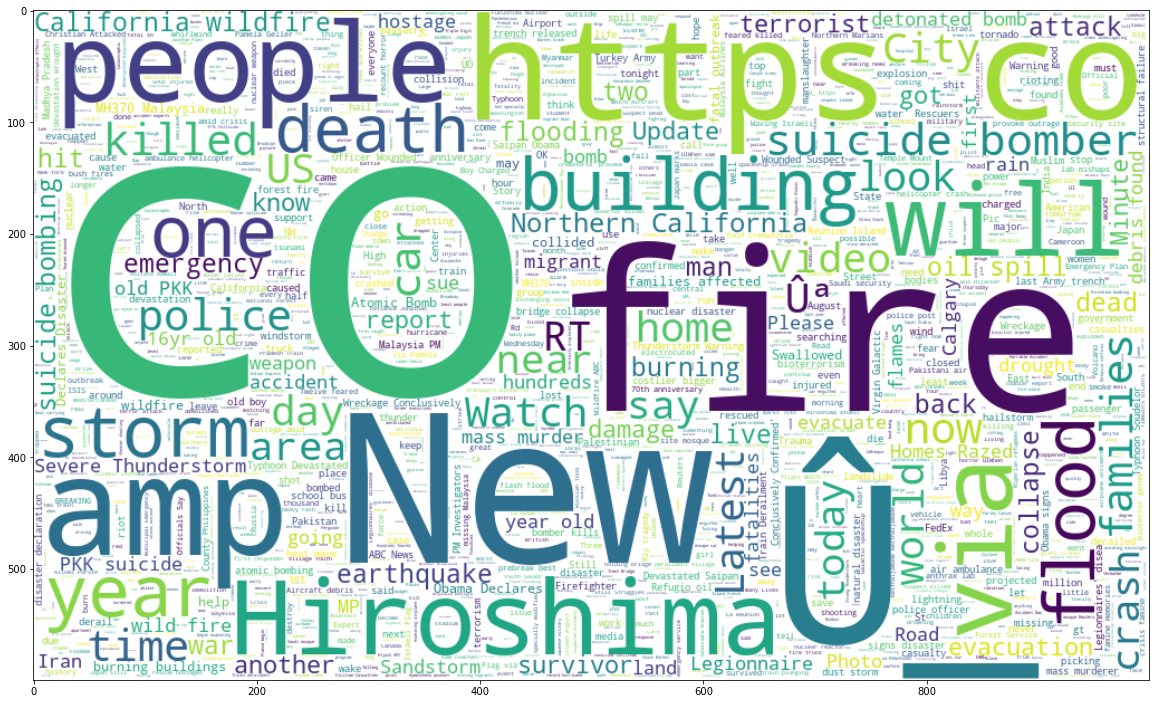

In [28]:
wordcloud_img(df[df['target'] == 1]['text'])

Облако слов для фейковых твитов

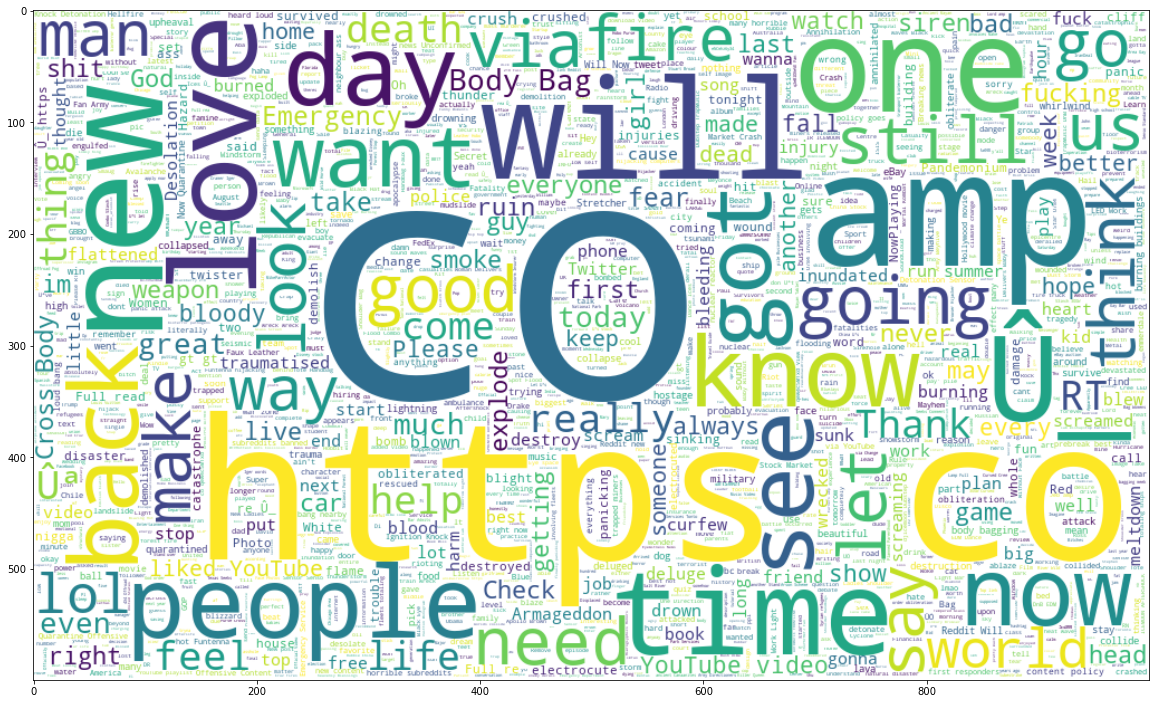

In [29]:
wordcloud_img(df[df['target'] == 0]['text'])

**Выводы:** поверхностно сравнивая два облака, на первый взгляд можно увидеть явные отличия. Например, сообщения о пожарах (fire), а также сообщения с приставкой New и такие бедствия как flood (наводнения) и storm (шторм), сообщения о смерти (death) чаще носят реальный характер (эти слова реже употребляются в переносном смысле), тогда как твиты содержащие такие слова как https, Love, оборот will (обозначающий, что что-то произойдёт в будущем) чаще имеют переносный (в контексте нашего проекта - фейковый) характер и не имеют под собой реальных оснований.


# 4. Подготовка признаков

# 4.1. Преобразование данных

### декодируем keywords

In [30]:
from urllib.parse import unquote

In [31]:
# выведем все слова с urlencoded-символами (у них всегда стоит знак "%")
for phrase in df['keyword']:
    phrase  = str(phrase)
    if('%' in phrase):
        print(phrase)

airplane%20accident
airplane%20accident
airplane%20accident
airplane%20accident
airplane%20accident
airplane%20accident
airplane%20accident
airplane%20accident
airplane%20accident
airplane%20accident
airplane%20accident
airplane%20accident
airplane%20accident
airplane%20accident
airplane%20accident
airplane%20accident
airplane%20accident
airplane%20accident
airplane%20accident
airplane%20accident
airplane%20accident
airplane%20accident
airplane%20accident
airplane%20accident
airplane%20accident
airplane%20accident
airplane%20accident
airplane%20accident
airplane%20accident
airplane%20accident
airplane%20accident
airplane%20accident
airplane%20accident
airplane%20accident
airplane%20accident
blew%20up
blew%20up
blew%20up
blew%20up
blew%20up
blew%20up
blew%20up
blew%20up
blew%20up
blew%20up
blew%20up
blew%20up
blew%20up
blew%20up
blew%20up
blew%20up
blew%20up
blew%20up
blew%20up
blew%20up
blew%20up
blew%20up
blew%20up
blew%20up
blew%20up
blew%20up
blew%20up
blew%20up
blew%20up
blew%20up


во всех случаях у нас закодирован только пробел знаком "%20", поэтому мы его просто заменим на обычный пробел

In [32]:
# делаем замену
for i, phrase in enumerate(df['keyword']):
    phrase  = str(phrase)
    if('%20' in phrase):
        df.loc[i, 'keyword'] = df.loc[i, 'keyword'].replace('%20', ' ')

# проверим
# выведем все слова с urlencoded-символами (у них всегда стоит знак "%")
for phrase in df['keyword']:
    phrase  = str(phrase)
    if('%' in phrase):
        print(phrase)

Т.к. ни одной фразы не выведено, но все замены прошли успешно и больше нет urlencoded-словосочетаний

In [33]:
# проверяем пропуски в cтолбцах
df.isna().sum()

id             0
keyword       61
location    2533
text           0
target         0
dtype: int64

### Заполним пропуcки

In [34]:
def location_and_keyword_fill_nan(df):
    #пропуски для keywords заменим на None
    df.keyword.fillna('None', inplace = True)

    #пропуски для location заменим на None
    df.location.fillna('None', inplace = True)

location_and_keyword_fill_nan(df)

# проверим
df.isna().sum()

id          0
keyword     0
location    0
text        0
target      0
dtype: int64

### Сбалансируем данные

Фейковых твитов у нас больше - 4342, реальных меньше - 3271.
Для балансировки данных нам надо перемешать фейковые твиты и обрезать на лишнее количество (на 1071 штук).
Количество лишних твитов будем считать как количество фейковых твитов минус колиество реальных твитов, т.е.:
> 4342 - 3271 = 1071

In [35]:
# вернём индексы тех элементов массива target (целевой переменной), где значение 0
target_np = df['target'].astype(int).to_numpy()
fake_twits_ids = np.argwhere(target_np == 0).flatten()
print('Всего fake_twits: ', len(fake_twits_ids))
fake_twits_ids

Всего fake_twits:  4342


array([  15,   16,   17, ..., 7584, 7587, 7593])

In [36]:
# перемешаем массив с id фейковых твитов
from sklearn.utils import shuffle
fake_twits_ids = shuffle(fake_twits_ids, random_state = 42)

# выберем в нем "лишние" id фейковых твитов
# т.е. возьмём все элементы после номера 3271 из перемешанного массива fake_twits_ids
fake_twits_ids_to_drop = fake_twits_ids[len(np.argwhere(target_np == 1).flatten()):]

# отображаем кол-во фейковых твитов, которые нужно выбросить из выборки для балансировки, а также их id
print(len(fake_twits_ids_to_drop))
fake_twits_ids_to_drop

1071


array([4982,  258, 3163, ..., 5359, 6520, 1328])

In [37]:
# т.к. данные пермешаны, то после отбрасыания лишних элементов, выборка будет репрезентативной
df_balanced = df.drop(df.index[fake_twits_ids_to_drop])

# отобразим итоговый размер признаков датасета
df_balanced.shape

(6542, 5)

In [38]:
# теперь видим, что классы сбалансированы.
df_balanced['target'].value_counts()

1    3271
0    3271
Name: target, dtype: int64

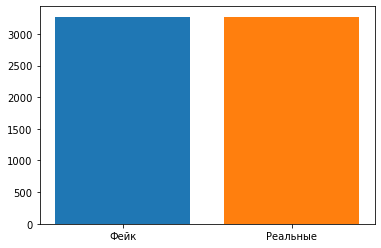

In [39]:
# гистограмма
df_balanced[df_balanced['target'] == 0]['target'].astype(int).hist(label='Фейк', grid = False, bins=1, rwidth=0.8)
df_balanced[df_balanced['target'] == 1]['target'].astype(int).hist(label='Реальные', grid = False, bins=1, rwidth=0.8)
plt.xticks((0,1),('Фейк', 'Реальные'))
plt.show()

### Новые категориальные переменные

Введём 2 новые категориальные переменные:
1. location_bool - факт наличия/отсутствия локации в твите.
2. keyword_bool - факт наличия/отсуствия ключевого слова в твите.

In [40]:
def location_and_keyword_to_bool_category(df):
    df.loc[df['location'] == 'None', 'location_bool'] = 0
    df.loc[df['location'] != 'None', 'location_bool'] = 1
    df.loc[df['keyword'] == 'None', 'keyword_bool'] = 0
    df.loc[df['keyword'] != 'None', 'keyword_bool'] = 1

location_and_keyword_to_bool_category(df_balanced)

# проверяем
df_balanced

,id,keyword,location,text,target,location_bool,keyword_bool
0,1,None,None,Our Deeds are the Reason of this #earthquake M...,1,0.0,0.0
1,4,None,None,Forest fire near La Ronge Sask. Canada,1,0.0,0.0
2,5,None,None,All residents asked to 'shelter in place' are ...,1,0.0,0.0
3,6,None,None,"13,000 people receive #wildfires evacuation or...",1,0.0,0.0
4,7,None,None,Just got sent this photo from Ruby #Alaska as ...,1,0.0,0.0
...,...,...,...,...,...,...,...
7608,10869,None,None,Two giant cranes holding a bridge collapse int...,1,0.0,0.0
7609,10870,None,None,@aria_ahrary @TheTawniest The out of control w...,1,0.0,0.0
7610,10871,None,None,M1.94 [01:04 UTC]?5km S of Volcano Hawaii. htt...,1,0.0,0.0
7611,10872,None,None,Police investigating after an e-bike collided ...,1,0.0,0.0


### Преобразуем текст в более удобный вид (обработаем URL, хэштеги и пользователей в тексте)

In [41]:
# делаем подобные преобразования до разбивки на train и test,т.к. такие преобразование каждого текста происходят независимо отвыборки
# к тому же X_train и X_test, которые образуются после train_test_split являются копиями базы и на копиях такие преобразования делать сложнее (может возвращаться ошибкао том, что работы ведутся на копии и т.п.)
# regular expressions library
import re

# функция для преобразования единичного текста
def single_text_clean(text):
    # преобразуем текст в нижний регистр
    text = text.lower()
    # преобразуем https:// и т.п. адреса в текст "URL"
    text = re.sub('((www\.[^\s]+)|(https?://[^\s]+))','URL',text)
    # преобразуем имя пользователя @username в "AT_USER"
    text = re.sub('@[^\s]+','AT_USER', text)
    # преобразуем множественые пробелы в один пробел
    text = re.sub('[\s]+', ' ', text)
    # преобразуем хэштег #тема в "тема"
    text = re.sub(r'#([^\s]+)', r'\1', text)
    return text

# функция для преобразования текста в разных столбцах датафрейма 
# (применяет предыдущую функцию single_text_clean к разным столбцам)
def text_columns_clean(df):
    text_columns_to_clean = ['keyword', 'location', 'text']
    for column in text_columns_to_clean:
        df.loc[:, column] = df[column].apply(single_text_clean)

text_columns_clean(df_balanced)

# проверим
df_balanced

,id,keyword,location,text,target,location_bool,keyword_bool
0,1,none,none,our deeds are the reason of this earthquake ma...,1,0.0,0.0
1,4,none,none,forest fire near la ronge sask. canada,1,0.0,0.0
2,5,none,none,all residents asked to 'shelter in place' are ...,1,0.0,0.0
3,6,none,none,"13,000 people receive wildfires evacuation ord...",1,0.0,0.0
4,7,none,none,just got sent this photo from ruby alaska as s...,1,0.0,0.0
...,...,...,...,...,...,...,...
7608,10869,none,none,two giant cranes holding a bridge collapse int...,1,0.0,0.0
7609,10870,none,none,AT_USER AT_USER the out of control wild fires ...,1,0.0,0.0
7610,10871,none,none,m1.94 [01:04 utc]?5km s of volcano hawaii. URL,1,0.0,0.0
7611,10872,none,none,police investigating after an e-bike collided ...,1,0.0,0.0


### Стоп-слова

Создадим словарь стоп-слов (которые не влияют на анализ, такие как he, have, it, the и т.п.), добавим к стоп-словам пунктуацию

In [42]:
import nltk
from nltk.corpus import stopwords
import string

stop = set(stopwords.words('english'))
punctuation = list(string.punctuation)
stop.update(punctuation)

### Stemming и Lemmatization

Используем Stemming (поиск основы слова) Lemmatization (приведение к нормальной форме: существительных к единственному числу, мужскому роду, глаголов к инфинитиву и т.п) для сокращения количества словоформ: am, are, is -> be; car, cars, car's, cars' -> car etc. https://ru.wikipedia.org/wiki/Стемминг https://ru.wikipedia.org/wiki/Лемматизация

In [43]:
# функция для определения прилагательных (ADJ), глаголов (VERB), существительных (NOUN) и наречий (ADV)
from nltk.corpus import wordnet as wn

def get_simple_pos(tag):
    if tag.startswith('J'):
        return wn.ADJ
    elif tag.startswith('V'):
        return wn.VERB
    elif tag.startswith('N'):
        return wn.NOUN
    elif tag.startswith('R'):
        return wn.ADV
    else:
        return wn.NOUN

# Лемматизация 
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag

# (отбрасываем всё лишнее в предложении, приводим слова к нормальной формеи получаем их список)
# 'Once upone a time a man walked into a door' -> ['upone', 'time', 'man', 'walk', 'door']
lemmatizer = WordNetLemmatizer()
def lemmatize_words(text):
    final_text = []
    for i in text.split():
        if i.strip().lower() not in stop:
            pos = pos_tag([i.strip()])
            word = lemmatizer.lemmatize(i.strip(),get_simple_pos(pos[0][1]))
            final_text.append(word.lower())
    return final_text   

# Объединяем лемматизированный список в предложение
# ['upone', 'time', 'man', 'walk', 'door'] -> 'upone time man walk door '
def join_text(text):
    string = ''
    for i in text:
        string += i.strip() +' '
    return string

# Запуск лемматизации и создание нового поля с лемматизированными предложениями 'text_lemma'
df_balanced.loc[:, 'text'] = df_balanced['text'].apply(lemmatize_words).apply(join_text)

# проверим
df_balanced

,id,keyword,location,text,target,location_bool,keyword_bool
0,1,none,none,deed reason earthquake may allah forgive u,1,0.0,0.0
1,4,none,none,forest fire near la ronge sask. canada,1,0.0,0.0
2,5,none,none,resident ask 'shelter place' notify officers. ...,1,0.0,0.0
3,6,none,none,"13,000 people receive wildfire evacuation orde...",1,0.0,0.0
4,7,none,none,get sent photo ruby alaska smoke wildfire pour...,1,0.0,0.0
...,...,...,...,...,...,...,...
7608,10869,none,none,two giant crane hold bridge collapse nearby ho...,1,0.0,0.0
7609,10870,none,none,at_user at_user control wild fire california e...,1,0.0,0.0
7610,10871,none,none,m1.94 [01:04 utc]?5km volcano hawaii. url,1,0.0,0.0
7611,10872,none,none,police investigate e-bike collide car little p...,1,0.0,0.0


# 4.2. Разбивка на train и test

In [44]:
# удалим не нужное нам больше дополнительное поле id (оно есть в индексе)
df_balanced = df_balanced.drop(['id'], axis=1)

from sklearn.model_selection import train_test_split

# разделение выборки на X и y
y = df_balanced['target']
X = df_balanced.drop(['target'], axis=1)

# разделение выборки на train и test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3,random_state=42)

# проверяем
X_train.shape

(4579, 5)

In [45]:
X_train

,keyword,location,text,location_bool,keyword_bool
1014,body bagging,none,ûïat_user ?????? caption need ??. freshman......,0.0,1.0
5536,radiation emergency,none,like at_user video url u canada radiation upda...,0.0,1.0
4295,hellfire,colorado,at_user say rude base experience. kind next le...,1.0,1.0
2423,derailed,"kalamazoo, michigan",three episode left end nigh,1.0,1.0
466,attack,none,volleyball attack ii volleyball training machi...,0.0,1.0
...,...,...,...,...,...
4379,hijacker,worldwide,rt notexplained: know image infamous hijacker ...,1.0,1.0
6071,sinkhole,texas af,damn sinkhole sunset????,1.0,1.0
6110,sinking,none,at_user lloyd london insure bet at_user sinkin...,0.0,1.0
6309,stretcher,none,sweater stretcher url url,0.0,1.0


# 4.3. Преобразование текста для моделирования

### TFIDF

TFIDFVectorizer каждому слову ставит частотность появления, при этом значение увеличивается пропорционально счету, но смещается на частоту слова в корпусе.

In [46]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Присвоение весов словам с использованием TfidfVectorizer
tv = TfidfVectorizer(min_df=0,max_df=1,use_idf=True,ngram_range=(1,2))
tv_X_train = tv.fit_transform(X_train['text'])
tv_X_test = tv.transform(X_test['text'])

print('TfidfVectorizer_train:', tv_X_train.shape)
print('TfidfVectorizer_test:', tv_X_test.shape)

TfidfVectorizer_train: (4579, 33051)
TfidfVectorizer_test: (1963, 33051)


In [47]:
# перевернём столбцы со словами из sparse матрицы с одним столбцом в numpy массив со многими столбцами
tv_X_train = tv_X_train.toarray()
tv_X_test = tv_X_test.toarray()

In [48]:
# Нормализуем данные в tv_X_train/test
from sklearn.preprocessing import StandardScaler

def scaling_train(tv_X_train):
    scaler_tv = StandardScaler(copy=False)
    tv_X_train_scaled = scaler_tv.fit_transform(tv_X_train)
    # трансформируем tv_X_train/test sparse numpy матрицы в pandas Data Frame
    tv_X_train_pd_scaled = pd.DataFrame(data=tv_X_train_scaled, 
                             index=X_train.index, 
                             columns=np.arange(0, np.size(tv_X_train_scaled,1)))
    return tv_X_train_pd_scaled, scaler_tv

def scaling_test(tv_X_test, scaler_tv):
    tv_X_test_scaled = scaler_tv.transform(tv_X_test)
    # трансформируем tv_X_train/test sparse numpy матрицы в pandas Data Frame
    tv_X_test_pd_scaled = pd.DataFrame(data=tv_X_test_scaled, 
                             index=X_test.index, 
                             columns=np.arange(0, np.size(tv_X_test_scaled,1)))
    return tv_X_test_pd_scaled

tv_X_train_pd_scaled, scaler_tv = scaling_train(tv_X_train)
tv_X_test_pd_scaled = scaling_test(tv_X_test, scaler_tv)

# проверяем
tv_X_train_pd_scaled.shape, tv_X_test_pd_scaled.shape

((4579, 33051), (1963, 33051))

In [49]:
# преобразуем pandas dataframe в numpy array для pytorch модели
tv_X_train_pd_scaled_arr = tv_X_train_pd_scaled.to_numpy()
tv_X_test_pd_scaled_arr = tv_X_test_pd_scaled.to_numpy()

In [50]:
tv_X_test_pd_scaled_arr

array([[-0.01477958, -0.01477958, -0.01477958, ..., -0.01477958,
        -0.01477958, -0.01477958],
       [-0.01477958, -0.01477958, -0.01477958, ..., -0.01477958,
        -0.01477958, -0.01477958],
       [-0.01477958, -0.01477958, -0.01477958, ..., -0.01477958,
        -0.01477958, -0.01477958],
       ...,
       [-0.01477958, -0.01477958, -0.01477958, ..., -0.01477958,
        -0.01477958, -0.01477958],
       [-0.01477958, -0.01477958, -0.01477958, ..., -0.01477958,
        -0.01477958, -0.01477958],
       [-0.01477958, -0.01477958, -0.01477958, ..., -0.01477958,
        -0.01477958, -0.01477958]])

# 5. Обучение модели и валидация


# Pytorch модель

In [51]:
import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

# funtools - работа с функциями высшего порядка
# partial - изменяет количество аргументов для переданных функций и запускает функции одну за другой
from functools import partial

# делаем результаты случайных разделений выборок воспроизводимыми (это аналог random_state в sklearn)
torch.manual_seed(42)

In [52]:
# Определяем девайс, на котором будет происходить тренировка (если у нас CPU, то будет на CPU, если GPU, то - не GPU)
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
device

device(type='cuda')

In [53]:
# класс для преобразования и загрузки данных в Pytorch
# он наследует класс Dataset
# df_tfidf - это df конвертированная в tf-idf (т.е. это матрица tv_X_train или tv_X_test)
# df - это сбалансированная база df_balanced

class TwitsDataset(Dataset):
    def __init__(self, tv_X_train_array, y_train):
        df = pd.DataFrame(index=y_train.index)
        
        # текст предварительно очищен, лематизирован и превращен в токены на предыдущих шагах
        df['tfidf_vector'] = [vector.tolist() for vector in tv_X_train_array]
        
        self.tfidf_vector = df.tfidf_vector.tolist()
        self.targets = y_train.tolist()
    
    def __getitem__(self, i):
        return (
            self.tfidf_vector[i],
            self.targets[i]
        )
    
    def __len__(self):
        return len(self.targets)

In [54]:
for i, vector in enumerate(tv_X_train):
    print(vector)
    vector.tolist()
    if(i ==  5): break

[-0.01477958 -0.01477958 -0.01477958 ... -0.01477958 -0.01477958
 -0.01477958]
[-0.01477958 -0.01477958 -0.01477958 ... -0.01477958 -0.01477958
 -0.01477958]
[-0.01477958 -0.01477958 -0.01477958 ... -0.01477958 -0.01477958
 -0.01477958]
[-0.01477958 -0.01477958 -0.01477958 ... -0.01477958 -0.01477958
 -0.01477958]
[-0.01477958 -0.01477958 -0.01477958 ... -0.01477958 -0.01477958
 -0.01477958]
[-0.01477958 -0.01477958 -0.01477958 ... -0.01477958 -0.01477958
 -0.01477958]


In [55]:
# загрузка данных в класс и их преобразование

# нормированные tf-idf
dataset = TwitsDataset(tv_X_train_pd_scaled_arr, y_train)

### Разделим на training и validation выборки
* Training: на ней будем обучать
* Validation: выборка для тюннга гипперпараметров (чтобы модель не переобучалась)
* Testing: для финальной оценки эффективности модели - эта выборка у нас уже есть (была определена на предыдущих шагаз выше)

In [56]:
# Т.к. тестовую выборку мы уже ранее формировали, то на данном шаге не будем её выделять из текущих данных (тестовая выборка в этот датасет не входит)
from torch.utils.data.dataset import random_split

def split_train_valid_test(corpus, valid_ratio=0.1, test_ratio=0.1):
    """Split dataset into train, validation, and test."""
    test_length = int(len(corpus) * test_ratio)
    valid_length = int(len(corpus) * valid_ratio)
    train_length = len(corpus) - valid_length - test_length
    return random_split(
        corpus, lengths=[train_length, valid_length, test_length],
    )

train_dataset, valid_dataset, test_dataset = split_train_valid_test(dataset, valid_ratio=0.2, test_ratio=0.0)
len(train_dataset), len(valid_dataset), len(test_dataset)
# это не значит, что Test-выборка у нас = 0, просто она определена в другом месте и называется tv_X_test 
# (а на данном шаге мы просто не выделяли тестовую выборку из tv_X_train, т.к. у нас уже есть tv_X_test)

(3664, 915, 0)

In [57]:
# проверим содержимое train_dataset
print('Число записей:', len(train_dataset), '\n')

import random
# генерация одних и тех же случайных величин
random.seed(a=42, version=2)

random_idx = random.randint(0,len(train_dataset)-1)
print('Случайны индекс из dataset:', random_idx, '\n')
tfidf_vector, sample_target = train_dataset[random_idx]
print('Размер вектора TF-IDF:', len(tfidf_vector), '\n')
print('Пример таргета:', sample_target, '\n')

Число записей: 3664 

Случайны индекс из dataset: 2619 

Размер вектора TF-IDF: 33051 

Пример таргета: 0 



In [58]:
# проверим содержимое valid_dataset
print('Число записей:', len(valid_dataset), '\n')

random.seed(a=42, version=2)
random_idx = random.randint(0,len(valid_dataset)-1)
print('Случайны индекс из dataset:', random_idx, '\n')
tfidf_vector, sample_target = valid_dataset[random_idx]
print('Размер вектора TF-IDF:', len(tfidf_vector), '\n')
print('Пример таргета:', sample_target, '\n')

Число записей: 915 

Случайны индекс из dataset: 654 

Размер вектора TF-IDF: 33051 

Пример таргета: 0 



In [59]:
# загрузчки данных для Pytorch (грузит данные по батчам)
BATCH_SIZE = 512

def collate(batch):
    tfidf = torch.FloatTensor([item[0] for item in batch])
    target = torch.LongTensor([item[1] for item in batch])
    return tfidf, target

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, collate_fn=collate)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, collate_fn=collate)

In [60]:
# посмотрим содержимое train_loader
print('Число training batches:', len(train_loader), '\n')

random.seed(a=42, version=2)
batch_idx = random.randint(0, len(train_loader)-1)
example_idx = random.randint(0, BATCH_SIZE-1)

print("Batch index: ", batch_idx)
print("Example index: ", example_idx)

for i, fields in enumerate(train_loader):
    tfidf, target = fields
    if i == batch_idx:
        print('Размер вектора TF-IDF:', len(tfidf[example_idx]), '\n')
        #print('Случайный TF-IDF: ', tfidf[example_idx], '\n')
        print('Тип TF-IDF: ', type(tfidf[example_idx]), '\n')
        #print('Случайный таргет: ', target[example_idx], '\n')
        print('Тип таргета: ', type(target[example_idx]), '\n')

Число training batches: 8 

Batch index:  1
Example index:  25
Размер вектора TF-IDF: 33051 

Тип TF-IDF:  <class 'torch.Tensor'> 

Тип таргета:  <class 'torch.Tensor'> 



In [61]:
# строим нейронную сеть (Вариант 2 - CNN на нормализованных TF-IDF)

class Flatten(nn.Module):
    def forward(self, input):
        return input.view(input.size(0), -1)

class Reorder(nn.Module):
    def forward(self, input):
        return input.permute((0, 2, 1))

class FeedfowardTextClassifier(nn.Module):
    def __init__(self, device, vocab_size, hidden1, hidden2, hidden3, hidden4, num_labels, batch_size):
        super(FeedfowardTextClassifier, self).__init__()
        self.device = device
        self.batch_size = batch_size

        self.convnet = nn.Sequential(
            nn.Conv1d(in_channels=vocab_size,
                      out_channels=hidden1, 
                      kernel_size=1),
            nn.ELU(),
            nn.Dropout(p=0.5),
            nn.Conv1d(in_channels=hidden1, 
                      out_channels=hidden2,
                      kernel_size=1, 
                      #stride=1
                     ),
            nn.ELU(),
            nn.Dropout(p=0.5),
        )
        self.fc = nn.Linear(hidden2, 2)
    
    def forward(self, x):
        batch_size = len(x)
        if batch_size != self.batch_size:
            self.batch_size = batch_size

        features = self.convnet(x)
        
        # после выполнения convnet удаляем 3-ее измерение (индекс = 2) размерностью 1
        features = features.squeeze(dim=2)
        
        prediction_vector = self.fc(features)
        return prediction_vector
        
# определяем размеры скрытых слоёв
HIDDEN1 = 512
HIDDEN2 = 128
HIDDEN3 = 128
HIDDEN4 = 128

tfidf_model = FeedfowardTextClassifier(
    vocab_size=len(tfidf_vector),
    hidden1=HIDDEN1,
    hidden2=HIDDEN2,
    hidden3=HIDDEN3,
    hidden4=HIDDEN4,
    num_labels=2,
    device=device,
    batch_size=BATCH_SIZE,
)

In [62]:
# переносим на GPU
tfidf_model = tfidf_model.to(device)
tfidf_model

FeedfowardTextClassifier(
  (convnet): Sequential(
    (0): Conv1d(33051, 512, kernel_size=(1,), stride=(1,))
    (1): ELU(alpha=1.0)
    (2): Dropout(p=0.5, inplace=False)
    (3): Conv1d(512, 128, kernel_size=(1,), stride=(1,))
    (4): ELU(alpha=1.0)
    (5): Dropout(p=0.5, inplace=False)
  )
  (fc): Linear(in_features=128, out_features=2, bias=True)
)

In [63]:
# Loss-функция и оптимизатор

from torch import optim
from torch.optim.lr_scheduler import CosineAnnealingLR

LEARNING_RATE = 4e-2

criterion = nn.CrossEntropyLoss().to(device)
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, tfidf_model.parameters()),
    lr=LEARNING_RATE,
)

scheduler = CosineAnnealingLR(optimizer, 1)

In [64]:
# определяем функцию и необходимые шаги для тренировки

def train_epoch(model, optimizer, train_loader):
    model.train()
    total_loss, total = 0, 0
    for i, (tfidf, target) in enumerate(train_loader):
        
        inputs = tfidf
        # добавляем новую размерность: канал для входа в cnn      
        inputs = inputs.unsqueeze(dim=2)
        
        #print(inputs.shape)
        
        # переносим на GPU
        inputs = inputs.to(device)
        target = target.to(device)
        
        # Reset gradient
        optimizer.zero_grad()
        
        # Forward pass
        output = model(inputs)
        
        # Compute loss
        loss = criterion(output, target)
        
        # Perform gradient descent, backwards pass
        loss.backward()

        # Take a step in the right direction
        optimizer.step()
        scheduler.step()

        # Record metrics
        total_loss += loss.item()
        total += len(target)

    return total_loss / total

# функция и шаги для валидации
def validate_epoch(model, valid_loader):
    model.eval()
    total_loss, total = 0, 0
    with torch.no_grad():
        for tfidf, target in valid_loader:
            inputs = tfidf
            
            # добавляем новую размерность: канал для входа в cnn
            inputs = inputs.unsqueeze(dim=2)
            
            # переносим на GPU
            inputs = inputs.to(device)
            target = target.to(device)
            
            #print("Val: ", inputs.shape)
            
            # Forward pass
            output = model(inputs)

            # Calculate how wrong the model is
            loss = criterion(output, target)

            # Record metrics
            total_loss += loss.item()
            total += len(target)

    return total_loss / total

In [65]:
# тренируем
from tqdm import tqdm

max_epochs = 50
n_epochs = 0
train_losses = []
valid_losses = []

for epoch_num in range(max_epochs):

    train_loss = train_epoch(tfidf_model, optimizer, train_loader)
    valid_loss = validate_epoch(tfidf_model, valid_loader)
    
    tqdm.write(
        f'эпоха #{n_epochs + 1:3d}\ttrain_loss: {train_loss:.2e}\tvalid_loss: {valid_loss:.2e}\n',
    )
    
    # Early stopping (ранняя остановка) если текущий valid_loss (значение функции ошибки для валидаионной выборки) больше чем 10 последних valid losses
    if len(valid_losses) > 7 and all(valid_loss >= loss for loss in valid_losses[-8:]):
        print('Stopping early')
        break
    
    
    train_losses.append(train_loss)
    valid_losses.append(valid_loss)
    
    n_epochs += 1

эпоха #  1	train_loss: 2.70e-01	valid_loss: 4.48e-01

эпоха #  2	train_loss: 1.08e-01	valid_loss: 1.90e-02

эпоха #  3	train_loss: 2.20e-02	valid_loss: 8.42e-03

эпоха #  4	train_loss: 6.78e-03	valid_loss: 8.09e-03

эпоха #  5	train_loss: 1.58e-02	valid_loss: 6.98e-02

эпоха #  6	train_loss: 4.76e-03	valid_loss: 6.47e-03

эпоха #  7	train_loss: 3.51e-03	valid_loss: 4.92e-03

эпоха #  8	train_loss: 2.45e-03	valid_loss: 3.83e-03

эпоха #  9	train_loss: 1.65e-03	valid_loss: 2.85e-03

эпоха # 10	train_loss: 1.37e-03	valid_loss: 2.13e-03

эпоха # 11	train_loss: 1.18e-03	valid_loss: 1.88e-03

эпоха # 12	train_loss: 1.20e-03	valid_loss: 1.79e-03

эпоха # 13	train_loss: 1.18e-03	valid_loss: 1.90e-03

эпоха # 14	train_loss: 1.19e-03	valid_loss: 1.96e-03

эпоха # 15	train_loss: 1.05e-03	valid_loss: 2.07e-03

эпоха # 16	train_loss: 1.10e-03	valid_loss: 2.09e-03

эпоха # 17	train_loss: 1.02e-03	valid_loss: 2.02e-03

эпоха # 18	train_loss: 9.79e-04	valid_loss: 2.04e-03

эпоха # 19	train_loss: 9.81e

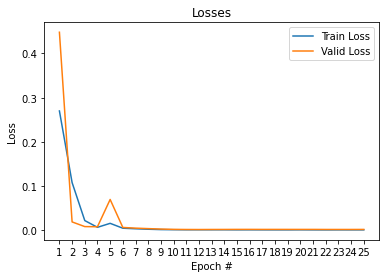

In [66]:
# строим график loss-функции после тренировки
epoch_ticks = range(1, n_epochs + 1)
plt.plot(epoch_ticks, train_losses)
plt.plot(epoch_ticks, valid_losses)
plt.legend(['Train Loss', 'Valid Loss'])
plt.title('Losses') 
plt.xlabel('Epoch #')
plt.ylabel('Loss')
plt.xticks(epoch_ticks)
plt.show()

# Прогнозируем таргет для тестовой выборки

In [67]:
# загрузка данных в класс и их преобразование
test_dataset = TwitsDataset(tv_X_test, y_test)

In [68]:
# загрузчки данных для Pytorch (грузит данные по батчам)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, collate_fn=collate)

In [69]:
# проверим содержимое test_loader
print('Число training batches:', len(test_loader), '\n')

random.seed(a=42, version=2)
batch_idx = random.randint(0, len(test_loader)-1)
example_idx = random.randint(0, BATCH_SIZE-1)

for i, fields in enumerate(test_loader):
    tfidf, target = fields
    if i == batch_idx:
        print('Размер вектора TF-IDF:', len(tfidf[example_idx]), '\n')
        print('Случайный таргет: ', target[example_idx], '\n')

Число training batches: 4 

Размер вектора TF-IDF: 33051 

Случайный таргет:  tensor(1) 



In [70]:
# Эффективность Pytorch CNN-модели на TFIDF
from sklearn.metrics import classification_report

tfidf_model.eval()
test_accuracy, n_examples = 0, 0
y_true, y_pred = [], []

with torch.no_grad():
    for tfidf, target in test_loader:
        # добавляем новую размерность: канал для входа в cnn
        tfidf = tfidf.unsqueeze(dim=2)
        
        inputs = tfidf.to(device)
        target = target.to(device)
        
        probs = tfidf_model(inputs)
        
        probs = probs.detach().cpu().numpy()
        predictions = np.argmax(probs, axis=1)
        target = target.cpu().numpy()
        
        y_true.extend(predictions)
        y_pred.extend(target)
        
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.43      0.56      0.48       757
           1       0.66      0.53      0.59      1206

    accuracy                           0.54      1963
   macro avg       0.54      0.54      0.53      1963
weighted avg       0.57      0.54      0.55      1963

